In [2]:
# packages
using Markdown
using InteractiveUtils
using NonlinearSolve
using StaticArrays
# files
using PKAssetPrices
import PKAssetPrices.Static: Parametrization, Model

## Trying to develop a comparison

### Show parameters

In [2]:
Static.AssetPK.model

nothing

                                                         Model
┌────────────────────────────────┬─────────────────────────────────────────────┬──────────────────────────────────────┐
│                      Variables │                                  Parameters │                            Equations │
│                     Amount: 17 │                                  Amount: 21 │                           Amount: 17 │
├────────────────────────────────┼─────────────────────────────────────────────┼──────────────────────────────────────┤
│                      Y: Output │       d0: autonomous credit financed demand │                      Y == ND + c * D │
│   ND: Non debt-financed demand │                         b: consumption rate │                          ND == b * Y │
│        D: debt-financed demand │           i1: inflation infuced policy rate │                     D == d0 - d1 * r │
│                 i: policy rate │                        W0: autonomous wages │                 

In [3]:
Static.AssetPKSDcompare.model

nothing

                                                         Model
┌────────────────────────────────┬─────────────────────────────────────────────┬──────────────────────────────────────┐
│                      Variables │                                  Parameters │                            Equations │
│                     Amount: 17 │                                  Amount: 22 │                           Amount: 17 │
├────────────────────────────────┼─────────────────────────────────────────────┼──────────────────────────────────────┤
│                      Y: Output │       d0: autonomous credit financed demand │                      Y == ND + c * D │
│   ND: Non debt-financed demand │                         b: consumption rate │                          ND == b * Y │
│        D: debt-financed demand │           i1: inflation infuced policy rate │                     D == d0 - d1 * r │
│                 i: policy rate │                        W0: autonomous wages │                 

### Show results

In [4]:
sol1 = solve_model(Static.AssetPK)

Solution
────────
Variables:      17 values
Sheets:         3
Model:          17 vars, 21 params, 17 eqs

Variable values
───────────────
Y  = 6.566017914628955
ND = 3.2830089573144776
D  = 4.103761196643096
i  = 0.09741726123444606
r  = 0.11202985041961298
P  = 1.7483452246889215
dL = 3.670979106894864
dM = 3.670979106894864
dR = 1.1012937320684593
W  = 1.9003752442270887
N  = 5.252814331703165
U  = 0.12453094471613924
SD = 0.387970149580387
AD = 0.7776403603148222
AP = 0.9978138208343181
AS = 0.7793441462502954
α  = 0.09989069104171591

Balance sheets
──────────────
  1: Private (assets=1, liabilities=1)
  2: Banks (assets=2, liabilities=2)
  3: CentralBank (assets=1, liabilities=1)


In [5]:
sol2 = solve_model(Static.AssetPKSDcompare)

Solution
────────
Variables:      17 values
Sheets:         3
Model:          17 vars, 22 params, 17 eqs

Variable values
───────────────
Y  = 6.566017914628954
ND = 3.283008957314477
D  = 4.103761196643096
i  = 0.09741726123444606
r  = 0.11202985041961297
P  = 1.7483452246889213
dL = -1.0289262964640038
dM = -1.0289262964640038
dR = -0.30867788893920106
W  = 1.9003752442270885
N  = 5.2528143317031635
U  = 0.12453094471613946
SD = -4.311935253778481
AD = 2.3308354045289894
AP = -3.6999054033588687
AS = -0.6299716210076607
α  = -0.13499527016794347

Balance sheets
──────────────
  1: Private (assets=1, liabilities=1)
  2: Banks (assets=2, liabilities=2)
  3: CentralBank (assets=1, liabilities=1)


#### Check alternative Specification

In [32]:
g = x -> solve_model(Static.@scenario Static.AssetPKSDcompare begin
    s2 = x
end)



#158 (generic function with 1 method)

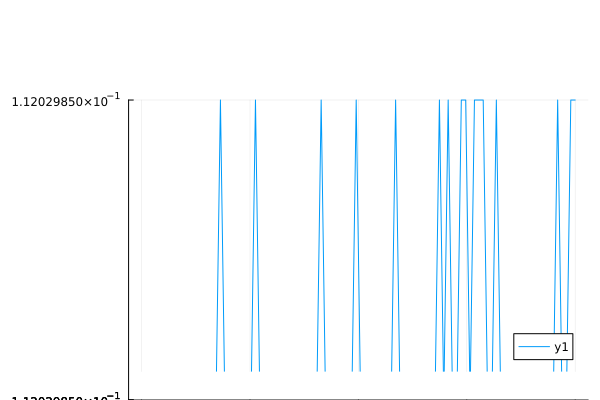

In [33]:
Plots.plot(LinRange(0.5,0.9,100),map(g.(LinRange(0.5,0.9,100))) do x 
   x.r
end)

In [11]:
scen1a = Static.@scenario Static.AssetPKSDcompare begin
    s2 = 0.80

end
sol_scen1a = solve_model(scen1a)


### ergo: irgendwie zwischen 0.85 und 1 gibts hier ne starke nichtlinearität – verstehen wir woher die kommt?

Solution
────────
Variables:      17 values
Sheets:         3
Model:          17 vars, 22 params, 17 eqs

Variable values
───────────────
Y  = 6.566017914628955
ND = 3.2830089573144776
D  = 4.103761196643096
i  = 0.09741726123444608
r  = 0.11202985041961298
P  = 1.7483452246889215
dL = 3.6572400306241075
dM = 3.6572400306241075
dR = 1.0971720091872321
W  = 1.9003752442270887
N  = 5.252814331703164
U  = 0.12453094471613921
SD = 0.3742310733096303
AD = 0.7615407293235912
AP = 0.9828261546615542
AS = 0.7748478463984663
α  = 0.09914130773307772

Balance sheets
──────────────
  1: Private (assets=1, liabilities=1)
  2: Banks (assets=2, liabilities=2)
  3: CentralBank (assets=1, liabilities=1)


In [ ]:
using MacroTools

ex2 = MacroTools.postwalk(sol_scen1a.model.model.equations[1].rhs) do x
    x isa Symbol && haskey(sol_scen1a.variables, x) ? sol_scen1a.variables[x] : x
    x isa Symbol && haskey(sol_scen1a.model.parameters, x) ? sol_scen1a.model.parameters[x] : x
end


:(3.2830089573144776 + c * 4.103761196643096)

In [13]:
sol_scen1a.variables

Dict{Symbol, Float64} with 17 entries:
  :α  => 0.0991413
  :AS => 0.774848
  :N  => 5.25281
  :ND => 3.28301
  :SD => 0.374231
  :D  => 4.10376
  :AD => 0.761541
  :Y  => 6.56602
  :AP => 0.982826
  :r  => 0.11203
  :dL => 3.65724
  :P  => 1.74835
  :U  => 0.124531
  :W  => 1.90038
  :dM => 3.65724
  :i  => 0.0974173
  :dR => 1.09717

### Get Balance Sheets

In [7]:
sol1.sheets

Assets,Value,Liabilities,Value
Deposits,3.67,Loans,3.67
Total,3.67,Total,3.67
Assets,Value,Liabilities,Value
Loans,3.67,Deposits,3.67
Reserves,1.1,Central Bank Credit,1.1
Total,4.77,Total,4.77
Assets,Value,Liabilities,Value
Central Bank Credit,1.1,Reserves,1.1
Total,1.1,Total,1.1


In [8]:
sol2.sheets

Assets,Value,Liabilities,Value
Deposits,-1.03,Loans,-1.03
Total,-1.03,Total,-1.03
Assets,Value,Liabilities,Value
Loans,-1.03,Deposits,-1.03
Reserves,-0.31,Central Bank Credit,-0.31
Total,-1.34,Total,-1.34
Assets,Value,Liabilities,Value
Central Bank Credit,-0.31,Reserves,-0.31
Total,-0.31,Total,-0.31
